# Problem: relativity

The case where the law is **an approximation you can truncate at the wrong
order**, and where a plausible numerical choice once produced a 56σ
refutation of general relativity.

In [1]:
import json, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import HTML, display
from physprior.viz import plots as P
from physprior.io import load_table, load_json
from physprior.config import get_settings
from physprior.benchmark.protocol import fit_arm

RESULTS = get_settings().results_dir
P.use_style()
pd.set_option("display.width", 160, "display.max_columns", 60)

def gif(path, width=560, caption=""):
    "Show an animation from figures/ without embedding it in the notebook."
    cap = f"<div style='color:#52514e;font-size:90%'>{caption}</div>" if caption else ""
    return HTML(f"<img src='../figures/{path}' width='{width}'>{cap}")

## 1 · The problem: two laws that are almost right

**Mercury.** Newton's orbit closes. Schwarzschild's does not: the relativistic
orbit equation carries one extra term,

$$\frac{d^{2}u}{d\varphi^{2}} + u = \frac{GM}{h^{2}}
+ \underbrace{\frac{3GM}{c^{2}}u^{2}}_{\text{general relativity}}$$

and that term advances the perihelion by 43 arcsec/century. It is **8×10⁻⁸**
of Mercury's acceleration, which makes this a numerics problem before it is a
physics problem.

**GW150914.** A binary inspiral radiates, so its frequency sweeps upward:

$$\dot{f} = \frac{96}{5}\pi^{8/3}
\left(\frac{G\mathcal{M}}{c^{3}}\right)^{5/3} f^{11/3}
\left[1 + \text{1PN} + \text{1.5PN} + \text{2PN} + \cdots\right]$$

That bracket is a **series**, and you choose where to stop. The question this
track exists to answer: *does anything in the fit tell you that you stopped
too early?*

## 2 · The data: created, then pulled

### 2a · Created: the precession, from the equation above

Integrated twice, with the GR term on and off. The difference is the
precession.

In [2]:
m = load_json("relativity", "problem_meta")
mp = m["simulations"]["mercury_precession"]
print(f"simulated GR precession : {mp['precession_arcsec_per_century']:.4f} arcsec/century")
print(f"analytic 6 pi GM/(c^2 a(1-e^2)) : {mp['analytic_arcsec_per_century']:.4f}")
print(f"agreement : {abs(mp['precession_arcsec_per_century']-mp['analytic_arcsec_per_century']):.2e} arcsec")

simulated GR precession : 42.9807 arcsec/century
analytic 6 pi GM/(c^2 a(1-e^2)) : 42.9807
agreement : 8.66e-06 arcsec


In [3]:
display(gif("relativity/schwarzschild_precession.gif", 460))
ld = m["simulations"]["light_deflection"]
print("Light bending at the solar limb:")
print(f"  general relativity, 4GM/c^2b : {ld['deflection_gr_arcsec']:.4f} arcsec")
print(f"  Newtonian half-value          : {ld['deflection_newtonian_arcsec']:.4f} arcsec")

Light bending at the solar limb:
  general relativity, 4GM/c^2b : 1.7512 arcsec
  Newtonian half-value          : 0.8756 arcsec


The perihelion is located by **root-finding `du/dφ`**, not by fitting a
parabola to a sampled grid. The shift is 5e-7 rad per orbit and a grid
estimate is good to ~1e-6, bigger than the effect. The first version of this
simulation duly reported a Newtonian "precession" 20% larger than the GR one.

### 2b · Pulled: LIGO strain, and Mercury's ephemeris

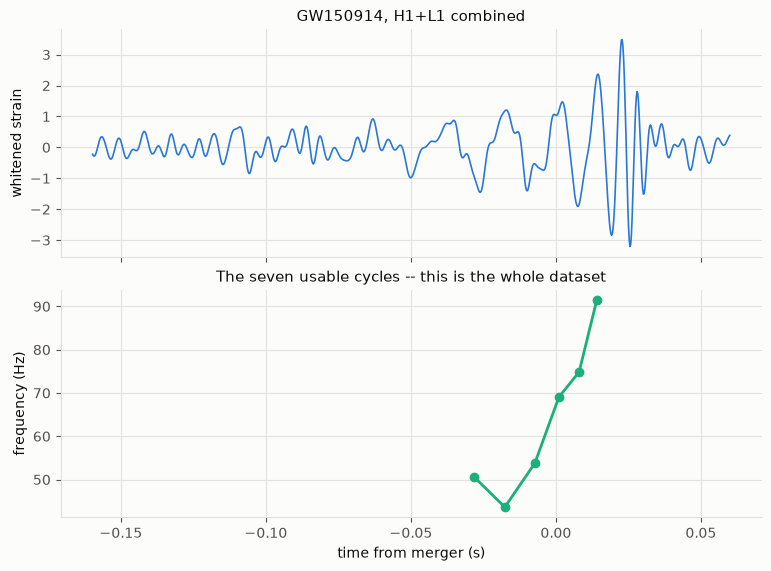

6 points. That is not a typo: the event's SNR of 24 is accumulated coherently over the waveform, and a per-cycle frequency needs per-cycle SNR.


In [4]:
from physprior.data.sources import gwosc as gw
tr = gw.frequency_track()
fig, axes = plt.subplots(2,1, figsize=(7.6,5.6), sharex=True)
w = (tr.strain_t>-0.16)&(tr.strain_t<0.06)
axes[0].plot(tr.strain_t[w], tr.strain_h[w], color=P.ARM_COLOR["physics"], lw=1.2)
axes[0].set_ylabel("whitened strain"); axes[0].set_title("GW150914, H1+L1 combined")
axes[1].plot(tr.t_s, tr.f_hz, "o-", color=P.ARM_COLOR["pinn"], markersize=6)
axes[1].set_xlabel("time from merger (s)"); axes[1].set_ylabel("frequency (Hz)")
axes[1].set_title("The seven usable cycles -- this is the whole dataset")
plt.show()
print(f"{len(tr.t_s)} points. That is not a typo: the event's SNR of 24 is "
      "accumulated coherently over the waveform, and a per-cycle frequency "
      "needs per-cycle SNR.")

## 3 · The method

Two different jobs travel under the name *physics-informed*, and this track does the following:

1. **Recovery**: measure a constant *inside* a law that is supplied. `physics` fits it classically with a covariance; `pinn` fits it with a neural correction alongside, and `w_phys` sets how much correction is allowed.

**Arms run here:** `oracle` · `physics` · `pinn` · `sr` · `nn`

**No discovery here.** Seven points cannot support a search over functional forms, so `sr` runs as a baseline rather than as a discovery method. The job is recovery: the chirp mass from GW150914, and the GR coefficient α from Mercury, which general relativity says is exactly 1.

This track's law **is a differential equation**, so its `pinn` arm is the residual PINN of Raissi et al. (panel A), not the law-plus-correction form the other tracks use. The chirp mass is an `nn.Parameter` inside the residual, so it receives a gradient through the physics term.

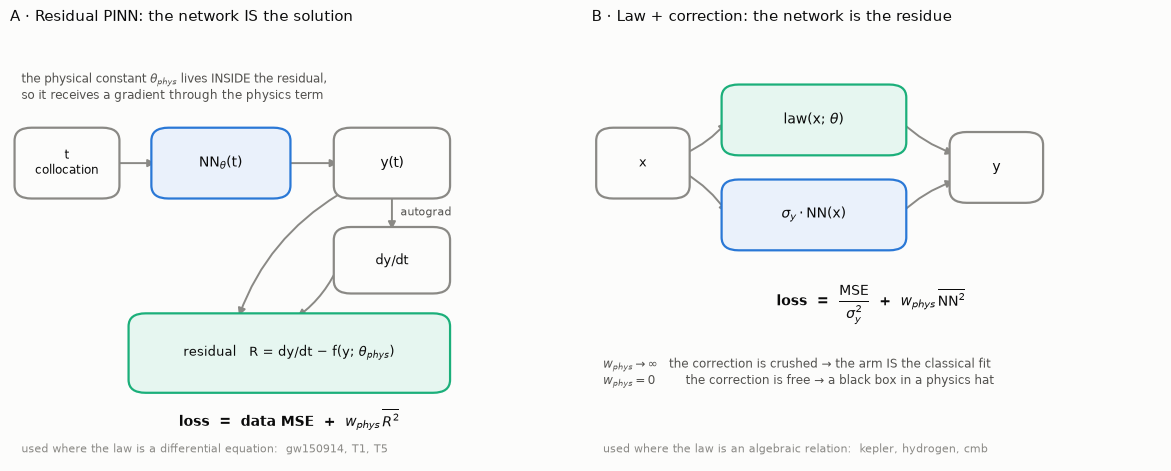

In [5]:
P.fig_pinn_anatomy(); plt.show()

## 4 · The results: does the fit notice a truncated law?

Same data, same code, same fitting; only the PN order changes.

In [6]:
gwm = load_json("relativity/gw150914", "meta")
ab = pd.DataFrame(gwm["pn_ablation"])
display(gif("relativity/gw150914/pn_ablation.png", 600))
ok = ab[ab.converged]
print(f"chirp mass spread across orders : {ok.Mc.max()-ok.Mc.min():.2f} Msun")
print(f"RMSE spread across orders       : {ok.rmse_hz.max()-ok.rmse_hz.min():.3f} Hz")
print("")
print("the 1PN row pinned to its bound and is excluded -- a parameter at its")
print("bound has not converged, whatever the optimiser reports")

chirp mass spread across orders : 9.32 Msun
RMSE spread across orders       : 0.167 Hz

the 1PN row pinned to its bound and is excluded -- a parameter at its
bound has not converged, whatever the optimiser reports


**Goodness of fit does not diagnose a wrong law.** At Newtonian order the
chirp mass is biased by ~+9 M☉ with a formal error of 4.1 (a confident wrong
answer) while the RMSE hardly moves.

### Is that bias real, or is it the pipeline's?

The only way to find out is to put a **known** answer through the identical
code.

In [7]:
inj = m["discovery"]["injection"]
print(f"injected Mc = {inj['mchirp_true']:.2f} M_sun, "
      f"{inj['n_usable']}/{inj['n_trials']} usable, "
      f"SNR threshold {inj['snr_threshold']}")
for k in ("pn0","pn3"):
    if k in inj:
        print(f"  {k}: injection bias {inj[k]['bias_pct']:+.1f}%")

injected Mc = 31.17 M_sun, 8/8 usable, SNR threshold 3.0
  pn0: injection bias +25.2%
  pn3: injection bias -1.2%


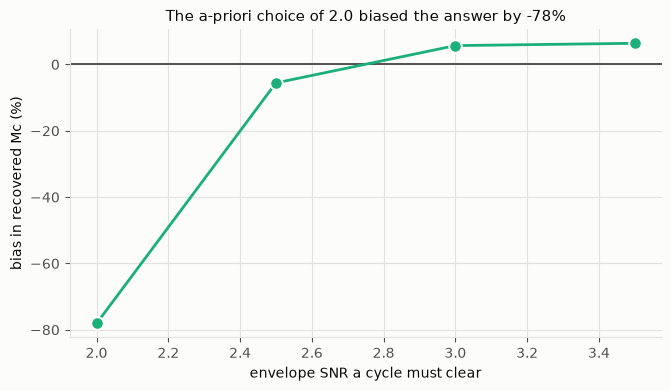

the value adopted (3.0) was chosen on the calibration injections and
never on the real event; the validation injections check it


In [8]:
tc = load_table("relativity","threshold_calibration")
fig, ax = plt.subplots(figsize=(6.6,3.8))
ax.axhline(0, color=P.INK_2, lw=1.4)
ax.plot(tc.snr_threshold, tc.bias_pct, "o-", color=P.ARM_COLOR["pinn"], markersize=9,
        markeredgecolor=P.SURFACE, markeredgewidth=1.4)
ax.set_xlabel("envelope SNR a cycle must clear"); ax.set_ylabel("bias in recovered Mc (%)")
b20 = float(tc.loc[tc.snr_threshold == 2.0, "bias_pct"].iloc[0])
ax.set_title(f"The a-priori choice of 2.0 biased the answer by {b20:+.0f}%")
plt.show()
print("the value adopted (3.0) was chosen on the calibration injections and")
print("never on the real event; the validation injections check it")

### Mercury: the result is α once it has stopped moving

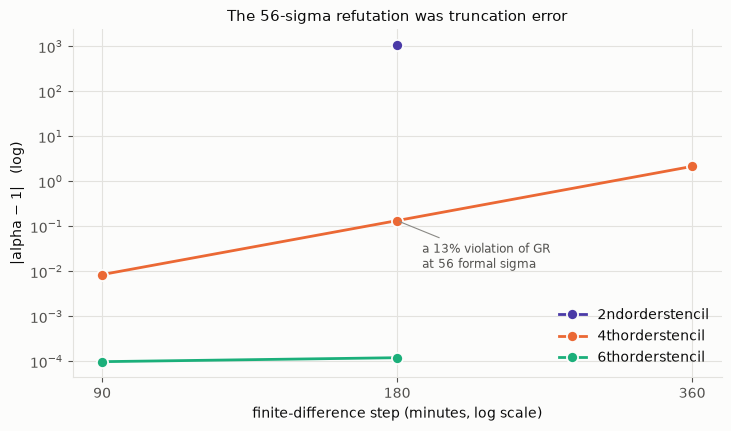

converged alpha = 1.000121 +- 0.000017   (Einstein: 1)


In [9]:
gm = load_json("relativity/mercury", "meta")
P.fig_alpha_convergence(gm["gr_convergence"]); plt.show()
gr = gm["gr"]
print(f"converged alpha = {gr['alpha_GR']:.6f} +- {gr['alpha_sigma']:.6f}   (Einstein: 1)")

---

## Conclusion

Everything below is rendered from `results/` at execution time by
`physprior.reporting.conclusions`: the verdicts, the margins and the prose.
A gap smaller than the seed-to-seed spread on the reporting seeds
(11 / 23 / 42) is reported as a **tie**, not rounded into a win.

In [10]:
from physprior.reporting import conclusions as C
verdicts = C.verdict_frame('relativity')
display(verdicts)

,track,question,winner,runner-up,margin,seed spread,verdict
0,relativity/gw150914,interpolation,physics,pinn,1.07x,0.14,TIE (within seed spread)
1,relativity/gw150914,data efficiency,pinn,nn,1.22x,0.16,TIE (within seed spread)
2,relativity/gw150914,noise,physics,pinn,1.27x,0.3,TIE (within seed spread)
3,relativity/gw150914,extrapolation,pinn,nn,1.33x,0.097,WIN
4,relativity/gw150914,parameter recovery (Mc),physics,pinn,1.12x,5.2,TIE (within seed spread)


In [11]:
from IPython.display import Markdown
display(Markdown(C.conclusion_markdown('relativity')))

Across 5 protocol questions on 1 track(s), **1 produced a decisive answer** and 4 were inside the seed-to-seed spread and are reported as ties rather than rounded into wins. **`pinn` takes 1 of the decisive question(s)**. The largest single gap is on **relativity/gw150914 / extrapolation**, where `pinn` beats `nn` by **1.33x**. The `pinn` arm (the one this project is built around) wins **1**, loses **0** and ties **4** of these, which is the number to read before any claim about what a physics prior buys.

In [12]:
lines = ["- " + line for line in C.what_would_change_this('relativity')]
display(Markdown("**What would change this conclusion**\n\n" + "\n".join(lines)))

**What would change this conclusion**

- `pinn` wins 1 question(s) (gw150914 extrapolation): the neural correction pays only when the law has something left over for it to absorb. Fitting the same track with the complete law would remove the residual it is exploiting and the win with it.
- 4 question(s) are ties: more seeds, or a lower-variance fit (ensembling, early stopping), would decide them either way.
- The 1.33x gap on relativity/gw150914 / extrapolation rests on three seeds with a spread of 0.097; it would be overturned by a seed set on which `nn` closes to within that spread, which is why the margin and the spread are printed side by side above.